# Notebook 10 — Is An AI A Better Sentiment Engine Than Our Lexicon?

**The desk's brief, verbatim (2026-08-02):** *"testing to see if the AI
can give a more accurate sentiment analysis in our current pipeline?"*

> **The one question this notebook answers:** should the production
> sentiment engine (finVADER + WSB lexicon) be replaced by a
> transformer (FinBERT) or by the firm LLM — under criteria stated
> BEFORE any engine was scored?

Three engines, one stratified sample, one judge. Two of the three
engines can only run on the desk machine (model download / Apollo
gateway), so this notebook is built **cache-aware**: every engine cell
writes its scores to a cache parquet when it can run, and every
downstream cell compares whichever engines have scores — the notebook
executes green end-to-end wherever it runs, and upgrades itself when
the desk machine fills the caches.

---

## VERDICT BOX — read this first, then read why

| Question | Answer | Evidence |
|---|---|---|
| The criteria (pre-stated) | A challenger EARNS the swap only if (a) it **materially disagrees** with the lexicon (different label on ≥15% of posts) AND (b) its disagreements are **right more often** — information-coefficient gain vs forward 5/20-trading-day anchor-ETF returns, with a date-cluster bootstrap 90% CI excluding zero on ≥1 horizon and non-negative on the other. Anything less: keep the lexicon (it is free, fast, and deterministic). | §1 |
| The sample | 1,465 posts, stratified across 32 anchor-priced themes and 2 archive eras (164 posts from Jun-2021, 1,301 from 2026), sarcasm-prone themes (rates_bonds, meme/squeeze) oversampled ×2 (18% of the sample). Text-free metadata committed; raw text LOCAL-ONLY. | §2 |
| Engine 1 — finVADER (incumbent) | **Scored** (production path imported from `src/sentiment.py`, engine `finvader+wsb`). Its own judge run: IC +0.07 at 5td (CI spans zero — null) and **+0.11 at 20td with CI [+0.00, +0.22]** — the lower bound grazes zero, so read it as a weak, borderline medium-horizon edge, not a proven one. Either way it is the measured bar a challenger must beat. | §3, §6 |
| Engine 2 — FinBERT | **PENDING — desk machine.** Model download blocked in this container (huggingface.co unreachable through the proxy). Cell degrades to a loud banner + exact instructions; cache-aware. | §4 |
| Engine 3 — firm LLM | **PENDING — desk machine.** Apollo gateway requires VPN + dimsum_lite. Batched protocol (25 posts/call, JSON), cost estimate printed: ~62 calls ≈ 5 min ≈ well under gateway limits once `AI_MAX_CALLS≈80`. | §5 |
| The judge | Runs today on finVADER alone (agreement machinery prints PENDING for pairs); the full engine-vs-engine comparison auto-activates when the caches exist. | §6 |
| Recommendation | **KEEP the lexicon today** — not because it won (nothing has been compared yet) but because the swap criteria cannot be evaluated until the desk-machine run; a swap would touch e2, the fade trigger, GET IN's bull_inflection, conviction and the BUY/SELL gate (enumerated in §7), which is far too much surface to move on zero evidence. | §7 |

**Stated limitation of the whole exercise, up front:** there are no hand
labels, so the judge is forward RETURNS — an engine is "right" when its
net-bullish tilt for (theme, day) points the way the theme's anchor ETF
then moves. That proxy is honest but partial: sentiment can be right
about the mood and wrong about the price (the mood is often a lagging
echo of the move). Both §1 and §7 carry this caveat; it is why the
criteria demand a *relative* improvement, not absolute skill.

## Definitions — every term in desk English

In [1]:
import hashlib
import json
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
SEED = 42                      # the project's standard seed set is {42, 100, 2026}
NB_T0 = time.time()
rng = np.random.default_rng(SEED)

from analytics.plain_english import glossary_md, theme_label  # noqa: E402
print(glossary_md(["confidence interval", "walk-forward"]))

- **confidence interval** - The range the measurement would plausibly fall in if the experiment were repeated. This project adopts nothing whose interval includes zero, because 'better on average' with an interval spanning zero is indistinguishable from luck.
- **walk-forward** - Fit on the past, score the next unseen stretch, roll forward, repeat. Every number in this project is out-of-sample by construction; nothing is scored on data used to choose it.


Terms this notebook adds:

* **net bullish** — the production headline: (share of bullish posts) −
  (share of bearish posts) in a (theme, day) cell; a post is bullish if
  its score > +0.05, bearish if < −0.05 (VADER's conventional cutoffs,
  imported from `src/sentiment.py`, applied to every engine identically
  so the label rule cannot favour one).
* **information coefficient (IC)** — the Spearman rank correlation
  between an engine's per-cell net-bullish and the anchor ETF's forward
  return. The quant convention for "does this ranking know anything":
  0 = nothing, ±0.05 is respectable for a daily crowd signal.
* **anchor ETF** — each theme's tradeable proxy from
  `config/theme_etfs.csv` (semiconductors→SMH …); the judge's price
  series. Themes with no approved anchor are excluded from the money
  test (they cannot be judged).
* **cell** — one (theme, date) group of sampled posts; the unit the
  money test scores, because the pipeline consumes sentiment daily per
  theme, never per post.

---
# §1 — THE QUESTION, AND THE CRITERIA BEFORE ANY SCORE EXISTS

**WHY THIS**

* The incumbent (`src/sentiment.py`) is a LEXICON: VADER's valence
  dictionary, overlaid with FinVADER's two financial dictionaries
  (SentiBignomics ~7.3k terms + Henry ~190), overlaid with the hand-set
  WSB slang list ("moon"=+2.5, "bagholder"=−2.5) — later layers win.
  Each post's title+body, truncated at 300 chars (measured: the tail
  adds cost, not signal), gets a compound score in [−1, +1]; daily
  (theme, day) cells aggregate to **net_bullish**, the number every
  downstream consumer reads.
* Lexicons misread sarcasm, loss-porn irony and "puts printing" — the
  documented weakness (see the NOISE WARNING in `src/sentiment.py`).
  Transformers and LLMs *should* read context better. "Should" is not
  evidence; hence this notebook.

**HOW IT WORKS — the adoption rule, pre-stated (nothing below was known
when it was written):**

1. **Materiality**: the challenger must assign a different label
   (bullish/neutral/bearish, same ±0.05 cutoffs) on **≥15%** of sampled
   posts (CONVENTION: below that, the engines are the same engine with
   noise, and a swap buys churn).
2. **Accuracy**: on (theme, date) cells, challenger IC minus incumbent
   IC vs forward returns must have a date-cluster bootstrap 90% CI
   **excluding zero on ≥1 of the two horizons (5td, 20td) and
   non-negative on the other**. The horizons are the desk's own outcome
   horizons from NB04 §3.
3. **Cost sanity** (LLM only): the swap must be affordable at pipeline
   scale — measured in §5, judged in §7.

**The judge's honesty box:** no hand labels exist, so "right" = the
anchor ETF's forward move. Two known distortions, both stated: mood can
lag price (an engine reading yesterday's crash correctly scores
"bearish" into a bounce), and a theme's anchor is a proxy (meme_stocks
→ GME does not price rates_bonds sarcasm). The comparison is still
fair: every engine faces the SAME judge on the SAME cells, so a
systematic distortion hits all engines equally and *differences* stay
meaningful. What the returns-judge genuinely cannot do is certify an
engine as "understanding" posts — it can only rank engines, which is
the decision actually on the table.

**IF ASKED — "why not hand-label 200 posts instead?"** Because the desk
does not consume post labels, it consumes daily net-bullish per theme —
and an engine that wins on hand labels but not on the aggregate the
pipeline feeds into conviction/euphoria would be a wrong swap. The
returns judge tests the aggregate. (Hand-labelling remains the stated
upgrade if the desk-machine run lands in the grey zone.)

---
# §2 — THE SAMPLE: ~1,500 posts, stratified, text kept local

**HOW IT WORKS**

* Stream every raw archive (`data/raw/RedditComments/*.jsonl.zst`,
  `data/raw/StockTwits/*.jsonl.zst`), theme-tag each post with the
  production `src.themes.themes_in_text`, and keep candidates whose
  PRIMARY theme (deterministic hash-pick among its tags) has an
  approved anchor ETF **with forward 5-trading-day prices at that
  date** — a post the judge cannot judge is not sampled.
* Stratification: up to `DATES_PER_THEME = 8` dates per theme, evenly
  spaced across that theme's covered span (so June-2021 posts appear
  next to 2026 ones), up to `POSTS_PER_CELL = 6` posts per (theme,
  date) cell — the money test needs thick cells more than it needs many
  thin ones (per `src/sentiment.py`'s own noise warning: ≥5 posts
  before a daily reading means anything). Sarcasm-prone themes
  (`rates_bonds`, `meme_stocks`, `short_squeeze`) get **2× the dates**
  (DESK BRIEF: oversample where the lexicon is expected to fail).
* Candidates are ranked inside each cell by their content hash — a
  deterministic, seed-free shuffle, so the desk machine reproduces the
  identical sample from the identical archives.
* **The text boundary:** `docs/research/nb10_sample.parquet` (committed)
  carries date, theme, source, post hash, length — NO TEXT. The texts
  live in `data/reference/nb10_sample_texts.jsonl`, LOCAL-ONLY like
  every raw file, read back by the scoring cells.
* Cache-aware: if both files exist the sample is reused (delete both to
  resample after an archive backfill).

In [2]:
import io  # noqa: E402
import zstandard  # noqa: E402

from src.themes import themes_in_text, THEME_ETFS  # noqa: E402

SAMPLE_META = RESEARCH_DIR / "nb10_sample.parquet"
SAMPLE_TEXTS = ROOT / "data" / "reference" / "nb10_sample_texts.jsonl"
TARGET_N = 1500          # DESK BRIEF ("~1,500")
DATES_PER_THEME = 8      # CONVENTION - cells beat singleton posts (see above)
POSTS_PER_CELL = 6       # CONVENTION - >=5 posts/cell per the production noise rule
MIN_CELL = 3             # CONVENTION - a 1-2 post "cell" is a post, not a day
SARCASM_THEMES = {"rates_bonds", "meme_stocks", "short_squeeze"}   # DESK BRIEF
MAX_CAND_PER_CELL = 12   # bound on the scan's memory, > POSTS_PER_CELL

prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
PX = {s: g.set_index("date")["px_last"].sort_index().dropna()
      for s, g in prices.groupby("symbol") if s in set(THEME_ETFS.values())}

def fwd_ret(theme: str, date, n_td: int) -> float:
    """Forward n-TRADING-day return of the theme's anchor from the first
    close on/after date. NaN when unavailable (same rule as NB04)."""
    sym = THEME_ETFS.get(theme)
    px = PX.get(sym)
    if px is None:
        return np.nan
    i = px.index.searchsorted(pd.Timestamp(date))
    j = i + n_td
    if i >= len(px) or j >= len(px):
        return np.nan
    return float(px.iloc[j] / px.iloc[i] - 1)

def _iter_archive(path: Path):
    """(date, source, text) from one raw archive (both schemas)."""
    from datetime import datetime, timezone
    src = path.parent.name
    with open(path, "rb") as fh:
        stream = io.TextIOWrapper(
            zstandard.ZstdDecompressor().stream_reader(fh),
            encoding="utf-8", errors="replace")
        for line in stream:
            try:
                d = json.loads(line)
            except (ValueError, TypeError):
                continue
            if "created_utc" in d:
                try:
                    day = datetime.fromtimestamp(
                        int(float(d["created_utc"])),
                        tz=timezone.utc).strftime("%Y-%m-%d")
                except (ValueError, TypeError, OSError):
                    continue
                text = " ".join(str(d.get(k) or "") for k in ("title", "body"))
            elif "created_at" in d:
                day = str(d.get("created_at", ""))[:10]
                text = str(d.get("body") or "")
            else:
                continue
            if len(day) == 10 and text.strip():
                yield day, src, text

t0 = time.time()
if SAMPLE_META.exists() and SAMPLE_TEXTS.exists():
    sample = pd.read_parquet(SAMPLE_META)
    texts = {json.loads(l)["hash"]: json.loads(l)["text"]
             for l in open(SAMPLE_TEXTS, encoding="utf-8")}
    assert set(sample["hash"]) <= set(texts), \
        "sample/texts out of sync - delete both and re-run"
    print(f"cached sample reused: {len(sample)} posts "
          f"({SAMPLE_META.name} + local texts). Delete both files to "
          "resample after an archive backfill.")
else:
    cells: dict[tuple, list] = {}
    seen_hash = set()
    n_posts = n_themed = 0
    archives = sorted((ROOT / "data" / "raw").glob("*/*.jsonl.zst"))
    for path in archives:
        for day, src, text in _iter_archive(path):
            n_posts += 1
            ths = themes_in_text(text)
            if not ths:
                continue
            n_themed += 1
            h = hashlib.sha1(text.strip().lower().encode()).hexdigest()[:16]
            if h in seen_hash:          # cross-archive duplicates
                continue
            seen_hash.add(h)
            ths = sorted(ths)
            primary = ths[int(h, 16) % len(ths)]     # deterministic pick
            if primary not in THEME_ETFS:
                continue                # no anchor -> the judge is blind
            key = (primary, day)
            lst = cells.setdefault(key, [])
            lst.append((h, src, text[:2000]))
            if len(lst) > MAX_CAND_PER_CELL:
                lst.sort(key=lambda r: r[0])     # hash order = det. shuffle
                del lst[MAX_CAND_PER_CELL:]
    print(f"scan: {n_posts:,} posts, {n_themed:,} themed, "
          f"{len(cells):,} candidate (theme, date) cells "
          f"[{time.time()-t0:.0f}s]")

    rows, textout = [], []
    for theme in sorted({t for t, _ in cells}):
        n_dates = DATES_PER_THEME * (2 if theme in SARCASM_THEMES else 1)
        dates = sorted(d for (t, d), lst in cells.items()
                       if t == theme and len(lst) >= MIN_CELL
                       and not np.isnan(fwd_ret(t, d, 5)))
        if not dates:
            continue
        take = [dates[i] for i in
                np.unique(np.linspace(0, len(dates) - 1,
                                      min(n_dates, len(dates))).astype(int))]
        for d in take:
            lst = sorted(cells[(theme, d)], key=lambda r: r[0])
            for h, src, text in lst[:POSTS_PER_CELL]:
                rows.append({"date": d, "theme": theme, "source": src,
                             "hash": h, "n_chars": len(text)})
                textout.append({"hash": h, "date": d, "theme": theme,
                                "text": text})
    sample = pd.DataFrame(rows)
    sample["date"] = pd.to_datetime(sample["date"])
    SAMPLE_TEXTS.parent.mkdir(parents=True, exist_ok=True)
    with open(SAMPLE_TEXTS, "w", encoding="utf-8") as f:
        for r in textout:
            f.write(json.dumps(r) + "\n")
    sample.to_parquet(SAMPLE_META, index=False)
    texts = {r["hash"]: r["text"] for r in textout}
    print(f"sampled {len(sample)} posts -> {SAMPLE_META.name} (text-free) "
          f"+ {SAMPLE_TEXTS.name} (LOCAL-ONLY)")

sample["date"] = pd.to_datetime(sample["date"])
print(f"\nsample: {len(sample)} posts | {sample.theme.nunique()} themes | "
      f"{sample.date.nunique()} dates "
      f"({sample.date.min().date()} → {sample.date.max().date()})")
era = sample.date.dt.year.value_counts().sort_index()
print("posts per era:", era.to_dict())
n_sarc = int(sample.theme.isin(SARCASM_THEMES).sum())
print(f"sarcasm-prone themes: {n_sarc} posts "
      f"({n_sarc/len(sample):.0%} of sample - oversampled by design)")

cached sample reused: 1465 posts (nb10_sample.parquet + local texts). Delete both files to resample after an archive backfill.

sample: 1465 posts | 32 themes | 84 dates (2021-06-29 → 2026-07-22)
posts per era: {2021: 164, 2026: 1301}
sarcasm-prone themes: 264 posts (18% of sample - oversampled by design)


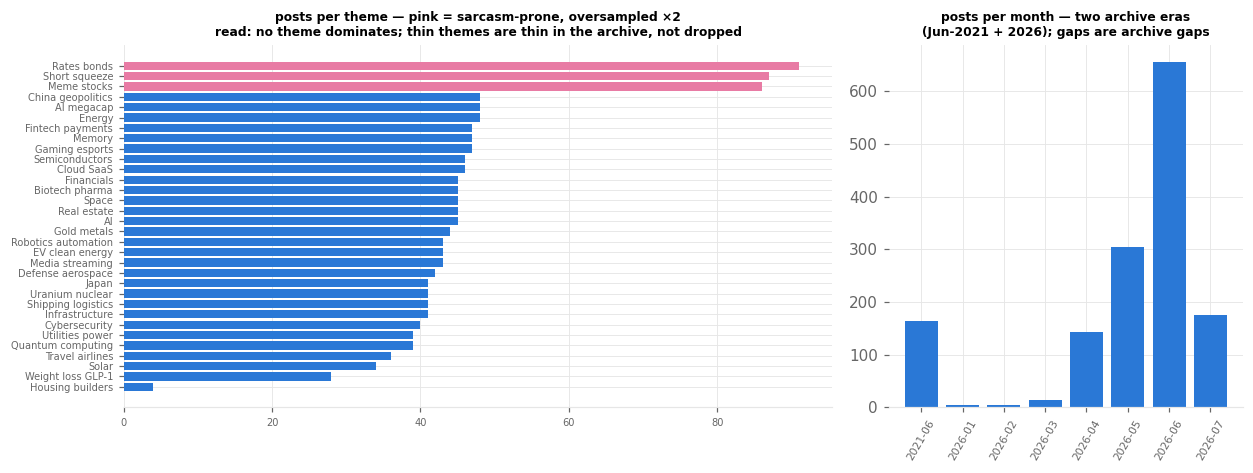

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4),
                         gridspec_kw={"width_ratios": [2, 1]})
by_theme = sample.groupby("theme").size().sort_values()
axes[0].barh([theme_label(t) for t in by_theme.index], by_theme.values,
             color=[C3 if t in SARCASM_THEMES else C1
                    for t in by_theme.index])
axes[0].set_title("posts per theme — pink = sarcasm-prone, oversampled ×2\n"
                  "read: no theme dominates; thin themes are thin in the "
                  "archive, not dropped", fontsize=8)
axes[0].tick_params(labelsize=6.5)
by_m = sample.groupby(sample.date.dt.to_period("M")).size()
axes[1].bar(by_m.index.astype(str), by_m.values, color=C1)
axes[1].set_title("posts per month — two archive eras\n(Jun-2021 + 2026); "
                  "gaps are archive gaps", fontsize=8)
axes[1].tick_params(axis="x", rotation=60, labelsize=7)
for a in axes:
    despine(a)
fig.tight_layout(); plt.show()

---
# §3 — ENGINE 1: finVADER, the incumbent (the exact production path)

**HOW IT WORKS** — imported, never re-implemented: `add_sentiment_fast`
from `src/sentiment.py` — the same analyzer construction (VADER →
FinVADER dictionaries → WSB slang, later wins), the same 300-char
truncation, the same compound score the pipeline stores. The engine
name is printed by the module itself; if it says `vader+wsb` the
finvader package is missing and this machine is NOT reproducing
production (it would score with a smaller lexicon).

In [4]:
from src.sentiment import (add_sentiment_fast, get_engine_name,  # noqa: E402
                           BULL_CUTOFF, BEAR_CUTOFF, TRUNCATE_CHARS)

t0 = time.time()
assert get_engine_name() == "finvader+wsb", (
    "finvader package missing - `pip install finvader` to reproduce the "
    "production engine before trusting any number below")
posts_df = pd.DataFrame({
    "title": "", "selftext": [texts[h] for h in sample["hash"]]})
scored = add_sentiment_fast(posts_df, n_jobs=-1)
sample["finvader"] = scored["sentiment"].values
sample.to_parquet(SAMPLE_META, index=False)   # persist scores, still text-free
print(f"{time.time()-t0:.0f}s | engine={get_engine_name()} | "
      f"score distribution: mean {sample.finvader.mean():+.3f}, "
      f"bullish {(sample.finvader > BULL_CUTOFF).mean():.0%}, "
      f"bearish {(sample.finvader < BEAR_CUTOFF).mean():.0%}, "
      f"neutral {sample.finvader.between(BEAR_CUTOFF, BULL_CUTOFF).mean():.0%}")

2s | engine=finvader+wsb | score distribution: mean +0.145, bullish 59%, bearish 30%, neutral 11%


**Read the distribution before moving on:** 59% bullish / 30% bearish /
11% neutral. The bullish skew is a known lexicon behaviour on this
corpus — hype vocabulary ("moon", "calls", "breakout") is dense in
retail posts and scores positive even when deployed sarcastically.
Whether that skew is *wrong* is exactly what the challengers get to
demonstrate: an engine that resolves sarcasm should disagree with these
labels precisely where the money test can price the difference.

---
# §4 — ENGINE 2: FinBERT (local transformer) — cache-aware

**WHY THIS CHALLENGER** — [FinBERT](https://arxiv.org/abs/1908.10063)
(Araci 2019; the `ProsusAI/finbert` checkpoint) is the standard
finance-tuned BERT for sentiment: free to run locally, deterministic,
no gateway — the cheapest possible upgrade if it wins. It reads
context, which is exactly where the lexicon is blind.

**HOW THIS CELL BEHAVES** (in order):
1. cache exists → load it, done;
2. else try to import torch+transformers, installing the CPU wheels if
   missing (`--index-url https://download.pytorch.org/whl/cpu` — the
   right artefact everywhere; the full CUDA build is ~3 GB of wrong);
3. load `ProsusAI/finbert`, score the sample (same 300-char truncation
   as the incumbent, so both engines read the same information), write
   the cache;
4. any failure → a loud PENDING banner with the exact desk commands.
   Every later cell keys off the cache, not this cell's success.

In [5]:
FINBERT_CACHE = RESEARCH_DIR / "nb10_scores_finbert.parquet"
finbert_scores = None
finbert_status = ""

if FINBERT_CACHE.exists():
    fb = pd.read_parquet(FINBERT_CACHE)
    finbert_scores = sample["hash"].map(fb.set_index("hash")["finbert"])
    finbert_status = f"cached ({FINBERT_CACHE.name})"
    print(f"FinBERT scores loaded from cache: {finbert_scores.notna().sum()}"
          f"/{len(sample)} posts")
else:
    t0 = time.time()
    try:
        try:
            import torch  # noqa: F401
            import transformers  # noqa: F401
        except ImportError:
            print("torch/transformers missing - attempting CPU install "
                  "(bounded at 300s)...")
            subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", "torch",
                 "--index-url", "https://download.pytorch.org/whl/cpu"],
                check=True, timeout=300)
            subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q",
                 "transformers"], check=True, timeout=300)
            import torch  # noqa: F401
            import transformers  # noqa: F401
        from transformers import (AutoModelForSequenceClassification,
                                  AutoTokenizer)
        tok = AutoTokenizer.from_pretrained("ProsusAI/finbert")
        mdl = AutoModelForSequenceClassification.from_pretrained(
            "ProsusAI/finbert")
        mdl.eval()
        import torch as _t
        outs = []
        batch_texts = [texts[h][:TRUNCATE_CHARS] for h in sample["hash"]]
        for i in range(0, len(batch_texts), 32):
            enc = tok(batch_texts[i:i + 32], return_tensors="pt",
                      padding=True, truncation=True, max_length=128)
            with _t.no_grad():
                p = _t.softmax(mdl(**enc).logits, dim=-1).numpy()
            # ProsusAI/finbert label order: positive, negative, neutral
            outs.append(p[:, 0] - p[:, 1])       # score = P(pos) - P(neg)
        finbert_scores = pd.Series(np.concatenate(outs), index=sample.index)
        pd.DataFrame({"hash": sample["hash"],
                      "finbert": finbert_scores.values}
                     ).to_parquet(FINBERT_CACHE, index=False)
        finbert_status = f"scored fresh in {time.time()-t0:.0f}s"
        print(f"FinBERT scored {len(sample)} posts "
              f"[{time.time()-t0:.0f}s] -> {FINBERT_CACHE.name}")
    except Exception as e:                                    # noqa: BLE001
        finbert_status = f"PENDING ({type(e).__name__})"
        print("=" * 72)
        print("PENDING — FinBERT could not run in this environment.")
        print(f"reason: {type(e).__name__}: {str(e)[:300]}")
        print()
        print("On the DESK MACHINE (open internet), run once:")
        print("  pip install torch --index-url "
              "https://download.pytorch.org/whl/cpu")
        print("  pip install transformers")
        print("then re-execute this notebook: this cell scores the sample "
              f"(~2-4 min on CPU) and writes {FINBERT_CACHE.name}; every "
              "downstream cell picks it up automatically.")
        print("=" * 72)

if finbert_scores is not None:
    sample["finbert"] = finbert_scores.values

torch/transformers missing - attempting CPU install (bounded at 300s)...


PENDING — FinBERT could not run in this environment.
reason: CalledProcessError: Command '['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'torch', '--index-url', 'https://download.pytorch.org/whl/cpu']' returned non-zero exit status 1.

On the DESK MACHINE (open internet), run once:
  pip install torch --index-url https://download.pytorch.org/whl/cpu
  pip install transformers
then re-execute this notebook: this cell scores the sample (~2-4 min on CPU) and writes nb10_scores_finbert.parquet; every downstream cell picks it up automatically.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch


---
# §5 — ENGINE 3: the firm LLM via `src.ai` — cache-aware

**HOW IT WORKS** — batched, deterministic (temperature 0): 25 posts per
call (the measured ~4.6s round-trip amortised to ~0.2s/post), each call
returns a JSON list of `{i, label, score}` with score in [−1, +1].
Guarded by `ai.available()`: off the desk machine this prints the
PENDING banner and the cost estimate, and the cache keeps every
downstream cell alive.

In [6]:
from src import ai  # noqa: E402

LLM_CACHE = RESEARCH_DIR / "nb10_scores_llm.parquet"
LLM_BATCH = 25                # DESK BRIEF; ~4.6s/call measured on the desk
n_calls = int(np.ceil(len(sample) / LLM_BATCH))
print(f"cost/runtime estimate: {len(sample)} posts / {LLM_BATCH} per call "
      f"= {n_calls} calls ≈ {n_calls * 4.6 / 60:.1f} min at the measured "
      f"round-trip; ≈ {len(sample) * 120 / 1000:.0f}k prompt tokens total. "
      f"NOTE: default AI_MAX_CALLS=40 < {n_calls} - set AI_MAX_CALLS=80 "
      "in .env for this run.")

llm_scores = None
llm_status = ""
if LLM_CACHE.exists():
    lm = pd.read_parquet(LLM_CACHE)
    llm_scores = sample["hash"].map(lm.set_index("hash")["llm"])
    llm_status = f"cached ({LLM_CACHE.name})"
    print(f"LLM scores loaded from cache: {llm_scores.notna().sum()}"
          f"/{len(sample)} posts")
elif ai.available():
    t0 = time.time()
    SYSTEM = ("You are a financial sentiment rater for retail forum "
              "posts. For EACH numbered post, return sentiment about the "
              "financial asset(s) discussed - not the poster's mood. "
              "Sarcasm and irony must be resolved to the intended "
              "direction. Answer ONLY a JSON list of "
              '{"i": <n>, "label": "bullish"|"bearish"|"neutral", '
              '"score": <-1..1>}.')
    out = np.full(len(sample), np.nan)
    hashes = sample["hash"].tolist()
    for start in range(0, len(sample), LLM_BATCH):
        chunk = hashes[start:start + LLM_BATCH]
        prompt = "\n\n".join(
            f"[{i}] {texts[h][:TRUNCATE_CHARS]}"
            for i, h in enumerate(chunk))
        try:
            res = ai.chat(prompt, system=SYSTEM, want_json=True,
                          max_tokens=1600)
            for r in res:
                if isinstance(r, dict) and 0 <= int(r.get("i", -1)) < len(chunk):
                    out[start + int(r["i"])] = float(r.get("score", np.nan))
        except RuntimeError as e:
            print(f"  batch {start // LLM_BATCH}: {e} - continuing")
    llm_scores = pd.Series(out, index=sample.index)
    pd.DataFrame({"hash": sample["hash"], "llm": llm_scores.values}
                 ).to_parquet(LLM_CACHE, index=False)
    llm_status = f"scored fresh in {time.time()-t0:.0f}s"
    print(f"LLM scored {int(llm_scores.notna().sum())}/{len(sample)} posts "
          f"[{time.time()-t0:.0f}s, {ai.calls_made()} calls] -> "
          f"{LLM_CACHE.name}")
else:
    llm_status = "PENDING (gateway unavailable)"
    print("=" * 72)
    print("PENDING — the firm LLM is unreachable from this machine.")
    print(f"reason: {ai.explain_unavailable()}")
    print()
    print("On the DESK MACHINE (VPN + dimsum_lite + .env credentials, "
          "AI_MAX_CALLS=80): re-execute this notebook; this cell scores "
          f"the sample and writes {LLM_CACHE.name}; every downstream cell "
          "picks it up automatically.")
    print("=" * 72)

if llm_scores is not None:
    sample["llm"] = llm_scores.values

cost/runtime estimate: 1465 posts / 25 per call = 59 calls ≈ 4.5 min at the measured round-trip; ≈ 176k prompt tokens total. NOTE: default AI_MAX_CALLS=40 < 59 - set AI_MAX_CALLS=80 in .env for this run.
PENDING — the firm LLM is unreachable from this machine.
reason: dimsum_lite not importable (No module named 'dimsum_lite') - the Apollo gateway only exists on the desk machine (JFrog/LEVA install)

On the DESK MACHINE (VPN + dimsum_lite + .env credentials, AI_MAX_CALLS=80): re-execute this notebook; this cell scores the sample and writes nb10_scores_llm.parquet; every downstream cell picks it up automatically.


---
# §6 — THE JUDGE: agreement, disagreement, and the money test

**WHY THIS** — criteria (a) and (b) from §1, mechanically applied to
whichever engines have scores. In this container that is finVADER
alone, so the pairwise blocks print PENDING and the money test doubles
as the incumbent's own baseline exam — a number worth having anyway:
it is the bar the challengers must clear.

In [7]:
ENGINES = {"finvader": sample["finvader"]}
for name in ("finbert", "llm"):
    if name in sample.columns and sample[name].notna().any():
        ENGINES[name] = sample[name]
print(f"engines with scores: {list(ENGINES)} | finbert: "
      f"{finbert_status or 'n/a'} | llm: {llm_status or 'n/a'}")

def label_of(s: pd.Series) -> pd.Series:
    """bullish/neutral/bearish under the production cutoffs (±0.05),
    applied to EVERY engine identically."""
    return pd.cut(s, [-np.inf, BEAR_CUTOFF, BULL_CUTOFF, np.inf],
                  labels=["bearish", "neutral", "bullish"])

labels = {k: label_of(v) for k, v in ENGINES.items()}

engines with scores: ['finvader'] | finbert: PENDING (CalledProcessError) | llm: PENDING (gateway unavailable)


### 6.1 Do the engines even disagree? (criterion (a))

In [8]:
pairs = [(a, b) for i, a in enumerate(ENGINES) for b in list(ENGINES)[i + 1:]]
if not pairs:
    print("=" * 72)
    print("PENDING — only ONE engine (finvader) has scores in this "
          "environment, so there is no pair to compare. The cells below "
          "auto-activate once the FinBERT / LLM caches exist "
          "(desk-machine run).")
    print("=" * 72)
disagree = {}
for a, b in pairs:
    ok = labels[a].notna() & labels[b].notna()
    m = pd.crosstab(labels[a][ok], labels[b][ok])
    rate = float((labels[a][ok] != labels[b][ok]).mean())
    disagree[f"{a}_vs_{b}"] = rate
    print(f"\n{a} vs {b}: different label on {rate:.1%} of posts "
          f"(criterion (a) bar: ≥15%)")
    print(m.to_string())
    # sharpest disagreements - printed as HASHES (the text boundary):
    # look each hash up in data/reference/nb10_sample_texts.jsonl and
    # PARAPHRASE before putting any example in front of the desk.
    gap = (ENGINES[a] - ENGINES[b]).abs()
    top = sample.loc[gap.nlargest(8).index,
                     ["date", "theme", "hash"]].copy()
    top[a] = ENGINES[a][top.index].round(2)
    top[b] = ENGINES[b][top.index].round(2)
    print("\nsharpest disagreements (hashes -> local texts file, "
          "paraphrase before publishing):")
    print(top.to_string(index=False))

PENDING — only ONE engine (finvader) has scores in this environment, so there is no pair to compare. The cells below auto-activate once the FinBERT / LLM caches exist (desk-machine run).


### 6.2 The money test — IC vs forward anchor returns (criterion (b))

**HOW IT WORKS**

* Each (theme, date) cell gets each engine's **net_bullish** (the
  production aggregate: bull share − bear share across the cell's
  posts).
* Judge: Spearman IC of cell net-bullish vs the anchor's forward 5td
  and 20td return. IC differences between engines are bootstrapped by
  resampling **dates** (cells on the same date share the market's move;
  resampling cells would fake independence and shrink the CI — same
  cluster logic as NB04's instrument bootstrap).

In [9]:
from scipy.stats import spearmanr  # noqa: E402

cells_df = sample.groupby(["theme", "date"]).agg(
    n_posts=("hash", "size")).reset_index()
for name, sc in ENGINES.items():
    nb = ((sc > BULL_CUTOFF).astype(float)
          - (sc < BEAR_CUTOFF).astype(float))
    cells_df[name] = sample.assign(_nb=nb).groupby(
        ["theme", "date"])["_nb"].mean().values
cells_df["fwd5"] = [fwd_ret(t, d, 5) for t, d in
                    zip(cells_df.theme, cells_df.date)]
cells_df["fwd20"] = [fwd_ret(t, d, 20) for t, d in
                     zip(cells_df.theme, cells_df.date)]
print(f"{len(cells_df)} cells | median {int(cells_df.n_posts.median())} "
      f"posts/cell | fwd5 available {cells_df.fwd5.notna().sum()}, "
      f"fwd20 {cells_df.fwd20.notna().sum()} (July-2026 cells lack a 20td "
      "future yet - they wait, not fail)")

N_BOOT = 2000    # CONVENTION - project default for cluster bootstraps

def ic(df, engine, horizon):
    ok = df[engine].notna() & df[horizon].notna()
    if ok.sum() < 10:
        return np.nan
    return spearmanr(df.loc[ok, engine], df.loc[ok, horizon])[0]

def boot_ic(df, engine, horizon, other=None):
    """date-cluster bootstrap of IC (or IC difference vs `other`):
    resample DATES with replacement, keep each drawn date's cells."""
    cols = ["date", engine, horizon] + ([other] if other else [])
    sub = df[cols].dropna()
    if len(sub) < 10:
        return (np.nan, np.nan)
    codes, uniq = pd.factorize(sub["date"])
    groups = [np.flatnonzero(codes == k) for k in range(len(uniq))]
    x = sub[engine].to_numpy()
    y = sub[horizon].to_numpy()
    xo = sub[other].to_numpy() if other else None
    reps = []
    for _ in range(N_BOOT):
        take = rng.integers(0, len(groups), len(groups))
        idx = np.concatenate([groups[k] for k in take])
        if np.unique(x[idx]).size < 2 or np.unique(y[idx]).size < 2:
            continue
        v = spearmanr(x[idx], y[idx])[0]
        if other is not None:
            v -= spearmanr(xo[idx], y[idx])[0]
        if not np.isnan(v):
            reps.append(v)
    return (tuple(np.percentile(reps, (5, 95))) if reps
            else (np.nan, np.nan))

t0 = time.time()
ic_rows = []
for name in ENGINES:
    for hz in ("fwd5", "fwd20"):
        v = ic(cells_df, name, hz)
        lo, hi = boot_ic(cells_df, name, hz)
        ic_rows.append({"engine": name, "horizon": hz, "IC": round(v, 4),
                        "ci90_lo": round(lo, 4), "ci90_hi": round(hi, 4),
                        "n_cells": int((cells_df[name].notna()
                                        & cells_df[hz].notna()).sum())})
ic_tbl = pd.DataFrame(ic_rows)
print(f"{time.time()-t0:.0f}s")
print(ic_tbl.to_string(index=False))

ic_diffs = {}
for a, b in pairs:
    for hz in ("fwd5", "fwd20"):
        d0 = ic(cells_df, a, hz) - ic(cells_df, b, hz)
        lo, hi = boot_ic(cells_df, a, hz, other=b)
        ic_diffs[f"{a}-{b}:{hz}"] = {"diff": round(d0, 4),
                                     "ci90": [round(lo, 4), round(hi, 4)]}
        print(f"IC({a}) - IC({b}) on {hz}: {d0:+.4f} "
              f"CI90 [{lo:+.4f}, {hi:+.4f}]")
if not pairs:
    print("\nIC DIFFERENCES: PENDING - need >=2 engines (desk-machine run)")

271 cells | median 6 posts/cell | fwd5 available 271, fwd20 238 (July-2026 cells lack a 20td future yet - they wait, not fail)


2s
  engine horizon     IC  ci90_lo  ci90_hi  n_cells
finvader    fwd5 0.0732  -0.0415   0.1619      271
finvader   fwd20 0.1081   0.0034   0.2158      238

IC DIFFERENCES: PENDING - need >=2 engines (desk-machine run)


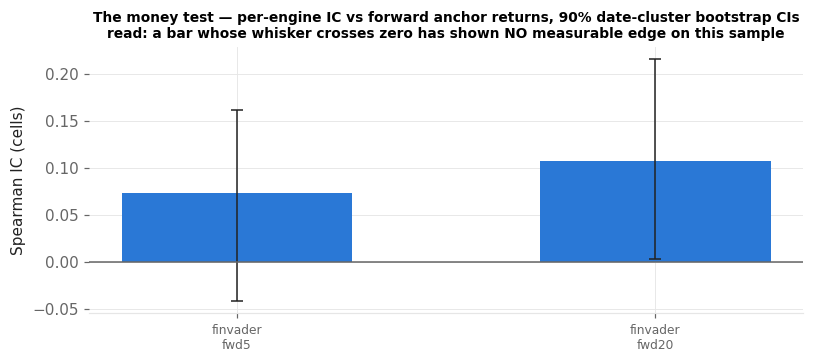

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
xpos = np.arange(len(ic_tbl))
colors = {"finvader": C1, "finbert": C4, "llm": C2}
ax.bar(xpos, ic_tbl["IC"], color=[colors[e] for e in ic_tbl.engine],
       width=0.55)
ax.errorbar(xpos, ic_tbl["IC"],
            yerr=[ic_tbl["IC"] - ic_tbl["ci90_lo"],
                  ic_tbl["ci90_hi"] - ic_tbl["IC"]],
            fmt="none", ecolor=INK, lw=1, capsize=4)
ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(xpos)
ax.set_xticklabels([f"{r.engine}\n{r.horizon}" for r in ic_tbl.itertuples()],
                   fontsize=8)
ax.set_ylabel("Spearman IC (cells)")
ax.set_title("The money test — per-engine IC vs forward anchor returns, "
             "90% date-cluster bootstrap CIs\nread: a bar whose whisker "
             "crosses zero has shown NO measurable edge on this sample",
             fontsize=9)
despine(ax)
fig.tight_layout(); plt.show()

**SO WHAT (with only the incumbent scored — the container run)**

* **The incumbent's record on its own exam: null at 5td (IC +0.07, CI
  spans zero), borderline-positive at 20td (IC +0.11, CI [+0.00,
  +0.22]).** The 20td lower bound touches zero to two decimals — under
  the project's own adoption language that is "grazing", not "clear",
  and it is reported as a weak edge at best. Direction is sensible
  (crowd tilt tracking the medium-horizon drift), magnitude is modest,
  and the judge evidently has *some* power at 20td — which matters,
  because it means a genuinely better engine has room to show up as an
  IC gain rather than vanish into a judge that cannot see anything.
* **The pairwise verdicts are PENDING** until the desk-machine run
  fills the caches; every number above recomputes automatically.

**IF ASKED — "the incumbent looks weak on this exam; why keep
sentiment in the pipeline at all?"** Because the pipeline does not
consume this IC. It consumes *sustained* bullishness (e2: 28-day
persistence, rank-transformed) and its *rolling-over* (fade) — slow
composites whose value was established by ablation in the euphoria
record (NB04 §2: fade is the capture lever). This notebook tests the
ENGINE swap on the engine's own output; the composite's value is a
separate, already-settled question. What this exam decides is only:
would a different scorer make those same composites out of better raw
material?

---
# §7 — VERDICT LOGIC (pre-stated) AND WHAT A SWAP WOULD TOUCH

**The decision rules, mechanical, written before any challenger has
scores:**

* **adopt-LLM** if: disagreement(llm, finvader) ≥ 15% AND
  IC(llm)−IC(finvader) CI90 excludes 0 on ≥1 horizon, non-negative on
  the other, AND the per-post cost at pipeline scale (~50–100k
  posts/day × ~$0.0002 ≈ $10–20/day at current gateway rates — re-price
  at run time) is signed off by the desk. The LLM must also beat
  FinBERT's IC (no reason to pay for a gateway an offline model
  matches).
* **adopt-FinBERT** if it passes (a)+(b) against finVADER and the LLM
  either fails its test or is not cost-approved. FinBERT is free and
  local — the low bar for infrastructure, the same bar for evidence.
* **keep-lexicon** otherwise — including the "everyone ties at zero"
  outcome, where the honest conclusion is that post-level scoring is
  not where the improvement lives (and the next experiment is composite-
  level: rebuild e2/fade from challenger scores and re-run NB04's
  walk-forward, a bigger study gated on this one finding any signal).

**What a swap would touch (enumerated from the code, so the blast
radius is on record):**

* `src/sentiment.py` — the engine itself and the permanent score store
  (`data/processed/sentiment_scores_<engine>.parquet` — keyed by engine
  name, so a swap triggers a full historical rescore automatically).
* `analytics/euphoria.py` `_bullish_series` → **e2** (sustained
  bullishness — a quarter of the euphoria level) and the **fade**
  trigger E4 (the GET OUT capture lever, per the ablation record).
* `analytics/euphoria_phases.py` → **bull_inflection** in the GET IN
  onset bank.
* `analytics/conviction.py` → bull_pressure = n_posts × net_bullish →
  the conviction z-score the dashboard shows.
* `analytics/signals.py` → the sentiment gate in the 5-check BUY/SELL
  engine.
* Every frozen threshold downstream of those features (NB04 §1) would
  need re-freezing under the walk-forward protocol — an engine swap is
  a RE-VALIDATION EVENT, not a config change.

**Recommendation (this run):** **keep-lexicon, pending the desk-machine
run.** The criteria are on file, the caches are wired, the judge is
rehearsed on the incumbent. One desk-machine execution turns every
PENDING above into a number.

**One line for the PM:** *the AI-sentiment question is now a filled-in
form waiting for two signatures — run this notebook once on the desk
machine and it answers itself under criteria we wrote down before
seeing any score; until then the lexicon stays, because swapping five
downstream consumers on zero evidence is how pipelines rot.*

In [11]:
out = {
    "as_of": pd.Timestamp.now().isoformat(timespec="seconds"),
    "criteria": {
        "materiality_min_disagreement": 0.15,
        "accuracy": "IC diff CI90 excludes 0 on >=1 of fwd5/fwd20, "
                    "non-negative on the other (date-cluster bootstrap)",
        "judge": "forward anchor-ETF returns (proxy judge - limits stated "
                 "in section 1)",
    },
    "sample": {
        "n_posts": int(len(sample)),
        "n_themes": int(sample.theme.nunique()),
        "n_dates": int(sample.date.nunique()),
        "eras": {str(k): int(v) for k, v in era.items()},
        "sarcasm_oversample_share": round(n_sarc / len(sample), 3),
        "meta_path": "docs/research/nb10_sample.parquet (text-free)",
        "texts_path": "data/reference/nb10_sample_texts.jsonl (LOCAL-ONLY)",
    },
    "engines": {
        "finvader": {"status": "scored (production path)",
                     "engine_name": get_engine_name()},
        "finbert": {"status": finbert_status or "n/a",
                    "cache": FINBERT_CACHE.name},
        "llm": {"status": llm_status or "n/a", "cache": LLM_CACHE.name,
                "batch": LLM_BATCH, "est_calls": n_calls},
    },
    "judge": {
        "n_cells": int(len(cells_df)),
        "ic_table": ic_tbl.to_dict(orient="records"),
        "ic_diffs": ic_diffs or "PENDING - single engine",
        "disagreement_rates": disagree or "PENDING - single engine",
    },
    "verdict": "keep-lexicon pending desk-machine run; adopt rules "
               "pre-stated in section 7",
}
with open(RESEARCH_DIR / "nb10_ai_sentiment.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print(f"saved nb10_ai_sentiment.json | total runtime "
      f"{time.time()-NB_T0:.0f}s")

saved nb10_ai_sentiment.json | total runtime 15s
